In [ ]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# List files in Drive
!ls "/content/drive/MyDrive"


'Colab Notebooks'   GPU_week#6	 resnet50_trained.pth   training.zip


In [ ]:
# Unzip dataset into Colab working directory
!unzip "/content/drive/MyDrive/training.zip" -d "/content/training"


Streaming output truncated to the last 5000 lines.
  inflating: /content/training/training/32/10656.0.jpg  
  inflating: /content/training/training/32/15385.2.jpg  
  inflating: /content/training/training/32/10746.2.jpg  
  inflating: /content/training/training/32/12932.2.jpg  
  inflating: /content/training/training/32/2278.7.jpg  
  inflating: /content/training/training/32/9420.4.jpg  
  inflating: /content/training/training/32/2564.12.jpg  
  inflating: /content/training/training/32/13998.20.jpg  
  inflating: /content/training/training/32/9984.4.jpg  
  inflating: /content/training/training/32/15504.166.jpg  
  inflating: /content/training/training/32/12550.2.jpg  
  inflating: /content/training/training/32/15549.7.jpg  
  inflating: /content/training/training/32/8502.0.jpg  
  inflating: /content/training/training/32/5352.3.jpg  
  inflating: /content/training/training/32/13152.0.jpg  
  inflating: /content/training/training/32/11003.1.jpg  
  inflating: /content/training/training

In [ ]:
# Verify extracted dataset structure
!ls /content/training/training


1   11	13  15	17  19	20  22	24  26	28  3	31  4  6  8
10  12	14  16	18  2	21  23	25  27	29  30	32  5  7  9


In [ ]:
# Import libraries
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split


In [ ]:
# Define dataset path
data_path = "/content/training/training"


In [ ]:
# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [ ]:
# Define transformations for validation (resize + normalize)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


In [ ]:
# Load dataset using ImageFolder
dataset = ImageFolder(data_path, transform=val_transform)

In [ ]:
# Display dataset information
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))
print("Total images:", len(dataset))


Classes: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '4', '5', '6', '7', '8', '9']
Number of classes: 32
Total images: 60514


In [ ]:
# Split dataset into training (80%) and validation (20%)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


In [ ]:
# Create data loaders for batching
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)


In [ ]:
# Check batch shape
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([8, 3, 224, 224]) torch.Size([8])


In [ ]:
# Import PyTorch and model architecture
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained ResNet50 model (ImageNet weights)
weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

# Modify final layer for 32-class classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 32)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


In [ ]:
# Define loss function and optimizer
from torch.optim.lr_scheduler import StepLR

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Learning rate scheduler (reduces LR every 7 epochs)
scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

In [ ]:
# Number of training epochs
epochs = 15

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training Loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Progress update every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    # Print average loss per epoch
    print(f"Epoch {epoch+1}/{epochs} completed. Avg Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/15 - Batch 0/6052 - Loss: 3.4572
Epoch 1/15 - Batch 100/6052 - Loss: 3.8214
Epoch 1/15 - Batch 200/6052 - Loss: 2.9318
Epoch 1/15 - Batch 300/6052 - Loss: 2.8848
Epoch 1/15 - Batch 400/6052 - Loss: 3.1719
Epoch 1/15 - Batch 500/6052 - Loss: 1.7167
Epoch 1/15 - Batch 600/6052 - Loss: 3.5984
Epoch 1/15 - Batch 700/6052 - Loss: 2.2837
Epoch 1/15 - Batch 800/6052 - Loss: 2.2424
Epoch 1/15 - Batch 900/6052 - Loss: 2.4252
Epoch 1/15 - Batch 1000/6052 - Loss: 2.0854
Epoch 1/15 - Batch 1100/6052 - Loss: 2.5702
Epoch 1/15 - Batch 1200/6052 - Loss: 2.1495
Epoch 1/15 - Batch 1300/6052 - Loss: 2.5081
Epoch 1/15 - Batch 1400/6052 - Loss: 2.1048
Epoch 1/15 - Batch 1500/6052 - Loss: 2.0118
Epoch 1/15 - Batch 1600/6052 - Loss: 2.1994
Epoch 1/15 - Batch 1700/6052 - Loss: 3.0896
Epoch 1/15 - Batch 1800/6052 - Loss: 1.9385
Epoch 1/15 - Batch 1900/6052 - Loss: 2.3955
Epoch 1/15 - Batch 2000/6052 - Loss: 2.7720
Epoch 1/15 - Batch 2100/6052 - Loss: 2.2695
Epoch 1/15 - Batch 2200/6052 - Loss: 2.4166


In [ ]:
# Validation / Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Print validation accuracy
print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 87.47%


In [ ]:
# Save trained model
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet50_trained.pth")

In [ ]:
# Load trained model for inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/resnet50_trained.pth"))

<All keys matched successfully>

In [ ]:
# Recreate model
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define same architecture as training
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 32)

model.to(device)

# Load trained weights
model.load_state_dict(torch.load("/content/drive/MyDrive/resnet50_trained.pth"))
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Define preprocessing
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
# Simple prediction function
from PIL import Image

class_names = dataset.classes

def predict_image(path):
    img = Image.open(path).convert("RGB")
    img_t = transform(img)
    img_t = img_t.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, pred = torch.max(outputs, 1)

    print("Predicted class:", class_names[pred.item()])


In [ ]:
# Recreate model for inference
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import torch.nn.functional as F

# Class labels
class_names = ['1','10','11','12','13','14','15','16','17','18','19','2',
               '20','21','22','23','24','25','26','27','28','29','3',
               '30','31','32','4','5','6','7','8','9']

# Load model architecture
weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 32)

# Load trained weights
model.load_state_dict(torch.load("/content/drive/MyDrive/resnet50_trained.pth", map_location="cpu"))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Preprocessing
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Predict function
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    print("Predicted class:", class_names[pred.item()])
    print("Confidence:", float(conf))

# Run prediction
predict_image("/content/562.9.jpg")

Predicted class: 20
Confidence: 0.9853298664093018


In [ ]:
# Confusion Matrix computation
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[ 20   0   0 ...   0   0   0]
 [  0   1   0 ...   0   1   0]
 [  0   0 423 ...   0  22   0]
 ...
 [  0   0   1 ...  59   1   0]
 [  0   0   4 ...   1 354   2]
 [  0   0   0 ...   0   3  53]]


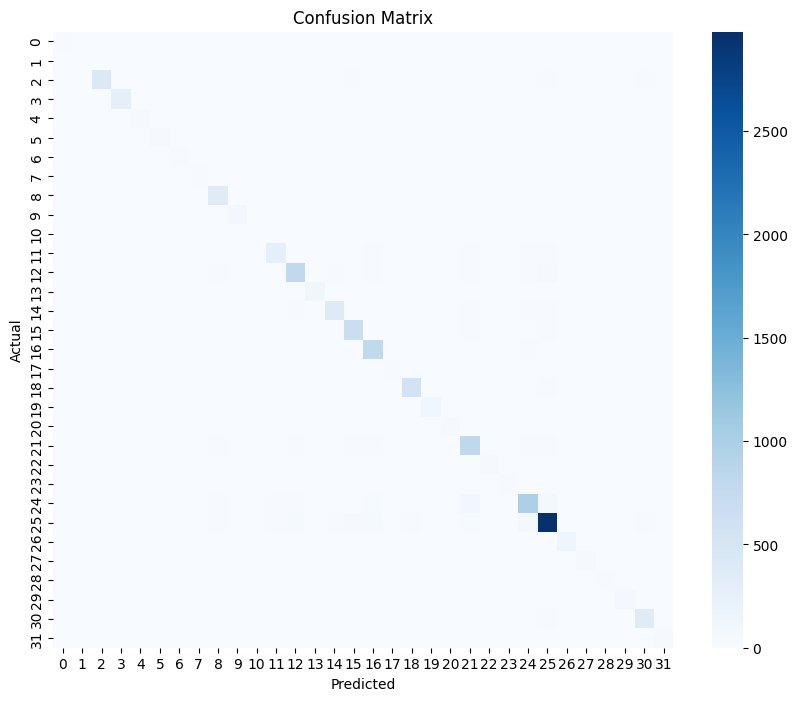

In [ ]:
# Confusion Matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Per-class accuracy calculation
class_correct = [0] * 32
class_total = [0] * 32

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (preds[i] == label).item()
            class_total[label] += 1

# Print accuracy for each class
for i in range(32):
    if class_total[i] > 0:
        print(f"Class {class_names[i]}: {100 * class_correct[i] / class_total[i]:.2f}%")

Class 1: 95.24%
Class 10: 50.00%
Class 11: 84.94%
Class 12: 93.73%
Class 13: 89.66%
Class 14: 90.32%
Class 15: 81.82%
Class 16: 80.00%
Class 17: 91.69%
Class 18: 92.22%
Class 19: 100.00%
Class 2: 78.75%
Class 20: 82.99%
Class 21: 77.12%
Class 22: 82.64%
Class 23: 92.45%
Class 24: 95.22%
Class 25: 93.55%
Class 26: 92.30%
Class 27: 89.60%
Class 28: 91.49%
Class 29: 85.22%
Class 3: 92.68%
Class 30: 86.67%
Class 31: 78.11%
Class 32: 89.06%
Class 4: 97.04%
Class 5: 91.49%
Class 6: 92.86%
Class 7: 95.16%
Class 8: 90.31%
Class 9: 89.83%
